<a href="https://colab.research.google.com/github/Anzonfire/Machine-Learning/blob/main/expno6/scenario%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

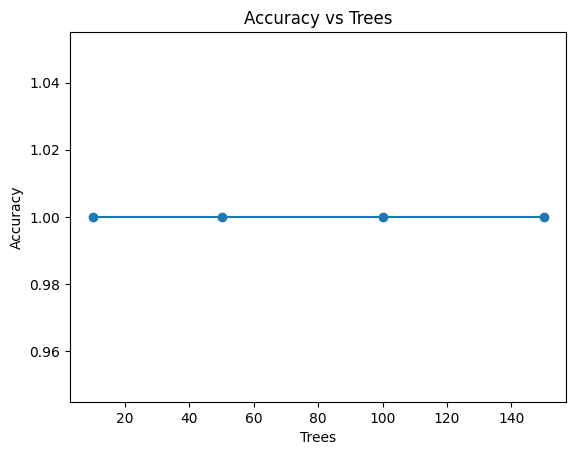

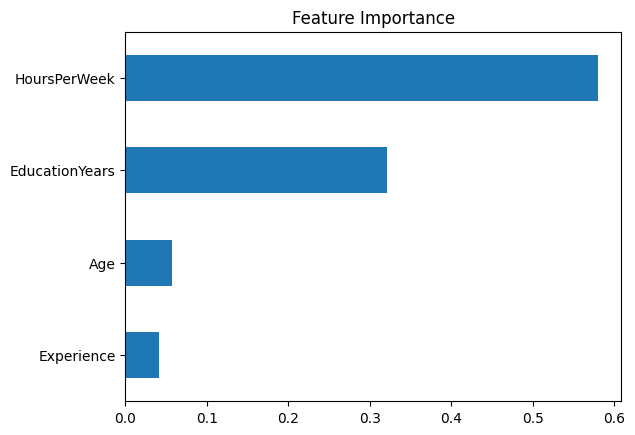

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE


df = pd.read_csv("income_random_forest.csv")

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

acc = []
trees = [10, 50, 100, 150]

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(trees, acc, marker='o')
plt.title("Accuracy vs Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()